In [101]:
import numpy as np
import matplotlib.pyplot as plt
from pysse import Electric_Field_Pulse, SSE

In [102]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [103]:
I = 1E4  # Intensity in W/cm^2
FWHM = 9.4  # FWHM in as
central_frequency = 250 # Pulse oscillation frequency in eV
dt = 5E-3

pulse_x = Electric_Field_Pulse(I=I, dt=dt, pulse_type='gaussian', FWHM=FWHM, omega_sin=central_frequency, time_span=8)
#pulse_y = Electric_Field_Pulse(I=I, dt=5E-3, pulse_type='gaussian', FWHM=FWHM, omega_sin=central_frequency, time_span=8)
#pulse_z = Electric_Field_Pulse(I=I, dt=5E-3, pulse_type='gaussian', FWHM=FWHM, omega_sin=central_frequency, time_span=8)

E_field = {"time": pulse_x.time, "pulse_x": pulse_x.pulse, "pulse_y": np.zeros_like(pulse_x.pulse), "pulse_z": np.zeros_like(pulse_x.pulse)}

In [104]:
print(pulse_x)

Electric Field Pulse:
  Intensity (I): 10000.0 W/cm^2
  FWHM: 9.4 as
  Central frequency: 9.18732590017419 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 0.1650270092543608 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 1600
  Pulse type: gaussian
  Time at maximum: 1.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.
  


In [105]:
propagation_method = "Heun"

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse')

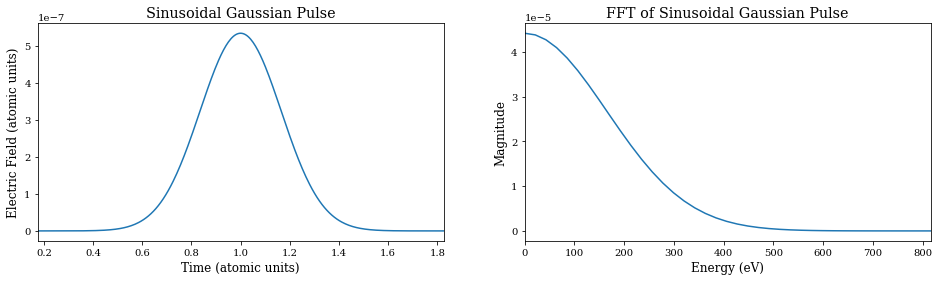

In [106]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(pulse_x.time, pulse_x.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field (atomic units)')
plt.xlim(pulse_x.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(pulse_x.freq, pulse_x.magnitude)
plt.xlim(pulse_x.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse')

In [107]:
Gamma = np.array([
    [0,1,2]
]) # [final state, initial state, gamma]

In [108]:
initial_conditions = np.array([
    [1,1.0]
])

In [109]:
n_paths = 30
n_jobs = 10
random_seed = 10 #Candidates: 10, 14, 16, 24, 2008

In [110]:
obj_sse = SSE("/home/sanchez/Trieste_Project/Chemistry/Scripts/SSE/dummy_data/", E_field, Gamma, initial_conditions, n_paths, propagation_method, n_jobs, random_seed)
print(obj_sse.matrix[:,:,0])
print(obj_sse.energies)
print(obj_sse.C_initial)
print(obj_sse.time.shape)

[[0.         0.03467016 0.10966274]
 [0.03467016 0.         0.03467016]
 [0.10966274 0.03467016 0.        ]]
[0.         0.18742145 0.20212117]
[0.+0.j 1.+0.j 0.+0.j]
(1600,)


In [111]:
p_0_0 = 0
p_1_0 = 1
p_0_th = 1 - p_1_0*np.exp(-obj_sse.Gamma[0,2]*obj_sse.time)
p_1_th = p_1_0*np.exp(-obj_sse.Gamma[0,2]*obj_sse.time)

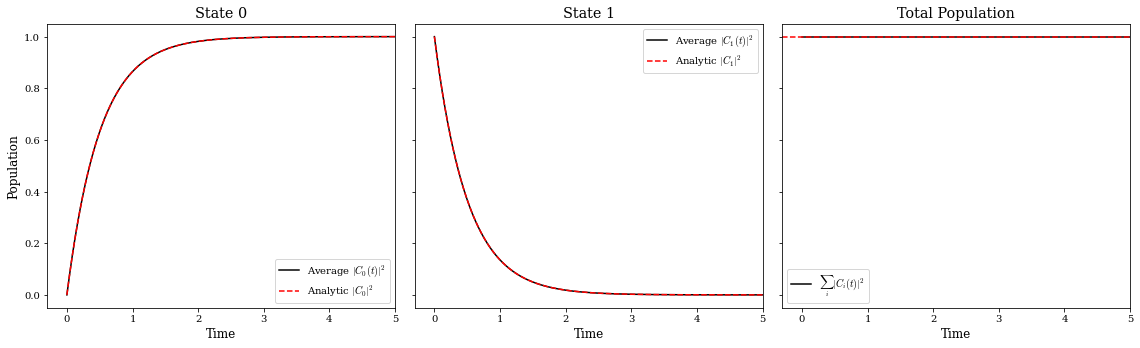

In [112]:
total_population = obj_sse.population_average[:,0] + obj_sse.population_average[:,1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Left subplot: |C_average[:,1]|^2 vs Analytic
axes[0].plot(obj_sse.time, obj_sse.population_average[:,0], label=r'Average $|C_0(t)|^2$', color='black')
axes[0].plot(obj_sse.time, p_0_th, label=r'Analytic $|C_0|^2$', color='red', linestyle='--')
axes[0].set_title('State 0')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population')
axes[0].set_xlim(-0.3, 5)
axes[0].legend()

# Middle subplot: |C_average[:,0]|^2 vs Analytic
axes[1].plot(obj_sse.time, obj_sse.population_average[:,1], label=r'Average $|C_1(t)|^2$', color='black')
axes[1].plot(obj_sse.time, p_1_th, label=r'Analytic $|C_1|^2$', color='red', linestyle='--')
axes[1].set_title('State 1')
axes[1].set_xlabel('Time')
#axes[1].set_ylabel('Population')
axes[1].set_xlim(-0.3, 5)
axes[1].legend()

# Right subplot: total population
axes[2].plot(obj_sse.time, total_population, label=r'$\sum_i |C_i(t)|^2$', color='black')
axes[2].axhline(1, color='red', linestyle='--')
axes[2].set_title('Total Population')
axes[2].set_xlabel('Time')
#axes[2].set_ylabel('Population')
axes[2].set_xlim(-0.3, 5)
axes[2].legend()

plt.tight_layout()
plt.show()

In [118]:
# --- c_t_1.dat ... c_t_28.dat: |C_j|^2 por archivo y suma entre archivos ---
import os

base_dir = "/home/sanchez/test_sse/first_test/RuKu4"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 30

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop = pop_sum/n_paths
variance = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std = np.sqrt(np.abs(variance))

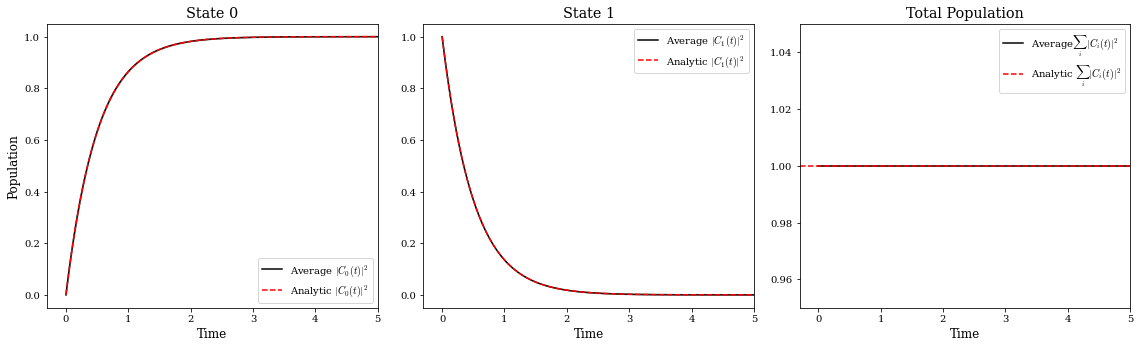

In [119]:
pop0_dat = pop[:, 0]
pop1_dat = pop[:, 1]
total_dat = pop.sum(axis=1)

pop0_std = pop_std[:, 0]
pop1_std = pop_std[:, 1]
total_std = pop_std.sum(axis=1)

p_0_0 = 0
p_1_0 = 1
p_0_th = 1 - p_1_0*np.exp(-obj_sse.Gamma[0,2]*t)
p_1_th = p_1_0*np.exp(-obj_sse.Gamma[0,2]*t)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left subplot: |C_average[:,1]|^2 vs Analytic
axes[0].plot(t, pop0_dat, label=r'Average $|C_0(t)|^2$', color='black')
axes[0].fill_between(t, pop0_dat - pop0_std, pop0_dat + pop0_std, color='black', alpha=0.2)
axes[0].plot(t, p_0_th, label=r'Analytic $|C_0(t)|^2$', color='red', linestyle='--')
axes[0].set_title('State 0')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population')
axes[0].set_xlim(-0.3, 5)
axes[0].legend()

# Middle subplot: |C_average[:,0]|^2 vs Analytic
axes[1].plot(t, pop1_dat, label=r'Average $|C_1(t)|^2$', color='black')
axes[1].fill_between(t, pop1_dat - pop1_std, pop1_dat + pop1_std, color='black', alpha=0.2)
axes[1].plot(t, p_1_th, label=r'Analytic $|C_1(t)|^2$', color='red', linestyle='--')
axes[1].set_title('State 1')
axes[1].set_xlabel('Time')
#axes[1].set_ylabel('Population')
axes[1].set_xlim(-0.3, 5)
axes[1].legend()

# Right subplot: total population
axes[2].plot(t, total_dat, label=r'Average$\sum_i |C_i(t)|^2$', color='black')
axes[2].fill_between(t, total_dat - total_std, total_dat + total_std, color='black', alpha=0.2)
axes[2].axhline(1, color='red', linestyle='--', label=r'Analytic $\sum_i |C_i(t)|^2$')
axes[2].set_title('Total Population')
axes[2].set_xlabel('Time')
#axes[2].set_ylabel('Population')
axes[2].set_xlim(-0.3, 5)
axes[2].set_ylim(0.95, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()